# ENN583 - Week 5 Prac 

## Motion from 3D-2D Correspondences: The Perspective-n-Point (PnP) Problem

In this practical, we will explore the problem of estimating the camera motion from a set of 3D-2D correspondences. This is known as the Perspective-n-Point (PnP) problem. We will use the OpenCV library to solve this problem and visualize the results.

In the lecture, we discussed the PnP problem and how it can be solved using different algorithms: The minimal solver P3P requires only 3 correspondences and can run efficiently inside a RANSAC loop. Then we can use a nonlinear least squares approach to refine the solution and find more accurate estimates for camera rotation and translation. 

In this practical, you can implement this pipeline and test it on the KITTI dataset.


### Setting things up

In [1]:
# This code cell is responsible for importing the `kitti_utils` module, which provides utilities for working with the KITTI dataset.
# It first attempts to find the repository root by looking for the presence of the `kitti_utils.py` file in the current directory and its parent directories. If it finds the file, it adds the `support` directory to the Python path so that the module can be imported. 
# If it cannot find the file, it raises a RuntimeError.
from pathlib import Path
import sys

support_dir = (Path.cwd().resolve().parents[1] / "support")
if str(support_dir) not in sys.path:
    sys.path.insert(0, str(support_dir))
    
import kitti_utils as kitti

In [4]:
# Load the KITTI sequence using the course support module.
data = kitti.load_kitti_dataset("2011_09_26_drive_0035")

import cv2
from matplotlib import pyplot as plt
import numpy as np

from spatialmath import *
from spatialmath.base import *
from spatialmath.base import sym
from spatialgeometry import *


In [18]:
def ransac_iterations(inlier_ratio, sample_size, confidence=0.99):
    """
    Minimum number of RANSAC iterations needed to have `confidence`
    probability of drawing at least one all-inlier minimal sample.

    inlier_ratio : estimated fraction of correspondences that are inliers (0-1)
    sample_size  : points needed per hypothesis (e.g. 3 for P3P, 5 for five-point, 8 for eight-point)
    confidence   : desired probability of success (default 0.99)
    """
    if inlier_ratio <= 0 or inlier_ratio >= 1:
        raise ValueError("inlier_ratio must be between 0 and 1 (exclusive)")

    numerator = np.log(1 - confidence)
    denominator = np.log(1 - inlier_ratio ** sample_size)
    return int(np.ceil(numerator / denominator))

### Implement PnP with RANSAC

In [ ]:
relative_motion = []

left_calibration = data.camera_calibration(camera=2)
right_calibration = data.camera_calibration(camera=3)
K = left_calibration['K']

T_right_left = right_calibration['T_cam_imu'] @ np.linalg.inv(left_calibration['T_cam_imu'])
baseline = np.linalg.norm(T_right_left[:3, 3])
fx, fy = K[0, 0], K[1, 1]
cx, cy = K[0, 2], K[1, 2]

# iterate over the complete sequence in the dataset
for frame in range(data.frame_count - 1):
    print(f"Processing frame {frame} of {data.frame_count - 1}")
    
    # Read the left and right image of the current frame and the left image from the next frame, then convert them to grayscale.
    left_current = cv2.cvtColor(data.stereo(frame)[0], cv2.COLOR_RGB2GRAY)
    right_current = cv2.cvtColor(data.stereo(frame)[1], cv2.COLOR_RGB2GRAY)
    left_next = cv2.cvtColor(data.stereo(frame + 1)[0], cv2.COLOR_RGB2GRAY)
    
    # calculate dense disparity for the current frame using the StereoSGBM algorithm
    # first set up the StereoSGBM object with appropriate parameters for the KITTI dataset
    # Typical OpenCV recommendations for the P1 and P2 parameters are: P1 = 8 * channels * blockSize**2; and P2 = 32 * channels * blockSize**2
    stereo = cv2.StereoSGBM_create(
        minDisparity=0,
        numDisparities=16 * 10,  # must be divisible by 16
        blockSize=5,
        P1=8 * 1 * 5 ** 2,   # P1: penalty for changing disparity by exactly one pixel. It discourages small fluctuations and surface noise.
        P2=32 * 1 * 5 ** 2,  # P2: penalty for changing disparity by more than one pixel. It strongly discourages sudden depth jumps.
        disp12MaxDiff=1,     # 1 enables the left-right consistency check.
        uniquenessRatio=10,  # like the ratio check: Requires the best disparity candidate to be sufficiently better than competing candidates. A value of 10 means that a match must pass a roughly 10% uniqueness margin.
        speckleWindowSize=100,  # Removes small connected regions of approximately similar disparity.
        speckleRange=32,     # Controls how much disparity variation is permitted while determining whether pixels belong to the same speckle component.
        preFilterCap=63,     
        mode=cv2.STEREO_SGBM_MODE_SGBM_3WAY        
    )
    
    
    # now calculate the disparity map for the current frame
    disparity = stereo.compute(left_current, right_current).astype(np.float32) / 16.0
    
    # extract ORB features from the left images of the current frame and the next frame
    # orb = ...
    # kp_current, des_current = ...
    # kp_next, des_next = ...
    
    # TODO: Implement this solution.
    orb = cv2.ORB_create(nfeatures=2000)
    kp_current, des_current = orb.detectAndCompute(left_current, None)
    kp_next, des_next = orb.detectAndCompute(left_next, None)
    
    # match the ORB features between the two frames using the Brute-Force-Matcher with Hamming distance
    # bf = ...
    # matches = bf.match(...)
    
    # TODO: Implement this solution.
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)
    matches = bf.match(des_current, des_next)
    
    # Remember that for P3P / PnP, we need the 3D coordinates of the matched keypoints in the CURRENT frame 
    # and their 2D coordinates in the NEXT frame, after the camera moved. 
    
    # Next we will calculate the 3D coordinates of the matched keypoints in the current camera frame using the disparity map and the camera calibration parameters.
    # To do that, we need the baseline, the focal length (in pixels) and the principal point (cx, cy) from the camera calibration parameters.
    # baseline = ...
    # focal_length = ...
    # cx, cy = ...
          
    # TODO: Implement this solution.
    baseline = baseline
    fx, fy = fx, fy
    cx, cy = cx, cy
    
    # We will store the 3D coordinates of the matched keypoints in the current frame, 
    # and their pixel coordinates in the next frame, in two separate lists.
    points_3d_current = []
    points_2d_next = [] 

    # Now we are ready to loop over the matches and calculate the 3D coordinates of the matched keypoints in the current frame using the disparity map and the camera calibration parameters.
    for match in matches:
        # get the coordinates of the matched keypoints in the left image of the current frame
        # pt_current = ...
        # pt_next = ...
        # TODO: Implement this solution.
        
        pt_current = kp_current[match.queryIdx].pt
        pt_next = kp_next[match.trainIdx].pt
                
        # get the disparity value for the matched keypoint in the current frame
        # disparity_value = ...
        # TODO: Implement this solution.
        u, v = int(round(pt_current[0])), int(round(pt_current[1]))
        disparity_value = disparity[v, u]
        
        # if the disparity value is valid (i.e., greater than 0), calculate the 3D coordinates using the triangulation formulas we saw in Week 3
        # Hint: Filtering only disparity > 0 admits very small disparities and therefore extremely uncertain, distant points. A minimum disparity or maximum-depth threshold might improve robustness.
        if disparity_value > 0:
            # first calculate the depth (Z coordinate) using the baseline and focal length from the camera calibration parameters        
            # Z = ...
            # then calculate the X and Y coordinates using the pixel coordinates, the principal point, and the depth Z
            # X = ...   
            # Y = ...
            # TODO: Implement this solution.
            Z = (fx * baseline) / disparity_value
            X = (pt_current[0] - cx) * Z / fx
            Y = (pt_current[1] - cy) * Z / fy
            
            # append the triangulated 3D point to the list
            points_3d_current.append([X, Y, Z])
            # also append the pixel coordinates of the matched keypoint in the next frame to its list
            points_2d_next.append([pt_next[0], pt_next[1]])

    # Now we are ready to run P3P followed by an iterative PnP refinement to estimate the camera pose (rotation and translation) of the next frame relative to the current frame.
    # Remember that we should always do P3P inside a RANSAC loop to reject outliers, and then refine the pose using an iterative PnP method (e.g., Levenberg-Marquardt) on the inliers.
    
    # P3P needs 4 matched points (3 for the relative pose information and 1 to resolve the ambiguity), so we only proceed if we have at least 4 matched points.     
    if len(points_2d_next) >= 4:
        
        # convert the 3d and 2d points to numpy arrays
        points_3d = np.array(points_3d_current)
        points_2d = np.array(points_2d_next)
        
        # for the next steps we also need K, the intrinsic camera calibration matrix, which we can get from the KITTI dataset using the `camera_calibration` function.
        K = data.camera_calibration(2)["K"]
        
        # use P3P in a RANSAC loop to estimate the camera pose (rotation and translation) of the next frame relative to the current frame
        # In the lecture I recommended using the `cv2.solvePnPRansac` function. Experiment with the different settings, e.g. AP3P vs P3P, different reprojection error thresholds, different number of RANSAC iterations, etc. to see how they affect the results.
        # Attention! Depending on the OpenCV version you are using, you might have to explicitly give the function a `distCoeffs=None` argument to avoid an error message.
        
        # ok, rvec, tvec, inliers = ...
        
        # TODO: Implement this solution.
        N = ransac_iterations(inlier_ratio=0.5, sample_size=3, confidence=0.99)
        ok, rvec, tvec, inliers = cv2.solvePnPRansac(points_3d, points_2d, K, flags=cv2.SOLVEPNP_AP3P, reprojectionError=1.25, distCoeffs=None, iterationsCount=N)
        
        # reshape the inliers to a 1D array of indices
        idx = inliers.flatten()
        
        # Now use the iterative least squares PnP method (e.g., Levenberg-Marquardt) to refine the camera pose estimate using only the inliers from the RANSAC step.        
        # Experiment with different settings and methods, e.g. you can use solvePnPRefineLM or solvePnPRefineVVS. 
        # You can also try different initial guesses for the rotation and translation vectors, e.g. you can use the output of the RANSAC step as the initial guess, or you can use the identity matrix and zero vector as the initial guess and see how that affects the results.
        # Check the lecture slides for a simple recipe of calling the `cv2.solvePnPRefineLM` function. You can also check the OpenCV documentation for more details on the different options and parameters.
        
        # rvec, tvec = ...

        # TODO: Implement this solution.
        rvec, tvec = cv2.solvePnPRefineVVS(points_3d[idx], points_2d[idx], K, None, rvec, tvec)
        
        # convert the rotation vector to a rotation matrix using the `cv2.Rodrigues` function, and then construct the SE3 transformation matrix from the rotation matrix and translation vector. 
        R = cv2.Rodrigues(rvec)[0]        
        T = SE3.Rt(R, tvec)
        T = T.inv()  # invert the transformation to get the relative motion from the current frame to the next frame
        
        # append the relative motion to the list
        relative_motion.append(T)
        
  

Processing frame 0 of 130
Processing frame 1 of 130
Processing frame 2 of 130
Processing frame 3 of 130
Processing frame 4 of 130
Processing frame 5 of 130
Processing frame 6 of 130
Processing frame 7 of 130
Processing frame 8 of 130
Processing frame 9 of 130
Processing frame 10 of 130
Processing frame 11 of 130
Processing frame 12 of 130
Processing frame 13 of 130
Processing frame 14 of 130
Processing frame 15 of 130
Processing frame 16 of 130
Processing frame 17 of 130
Processing frame 18 of 130
Processing frame 19 of 130
Processing frame 20 of 130
Processing frame 21 of 130
Processing frame 22 of 130
Processing frame 23 of 130
Processing frame 24 of 130
Processing frame 25 of 130
Processing frame 26 of 130
Processing frame 27 of 130
Processing frame 28 of 130
Processing frame 29 of 130
Processing frame 30 of 130
Processing frame 31 of 130
Processing frame 32 of 130
Processing frame 33 of 130
Processing frame 34 of 130
Processing frame 35 of 130
Processing frame 36 of 130
Processing 

### Let's visualise the results and compare with the ground truth

This follows last week's practical: We use the ground truth poses stored in `data.ground_truth_pose(i)` to compare with the estimated poses. To chain the estimated trajectory together, we get `T_cam_imu` from the calibration file and use it to transform the estimated poses into the IMU frame. The ground truth poses are already in the IMU frame, so we can directly compare them.


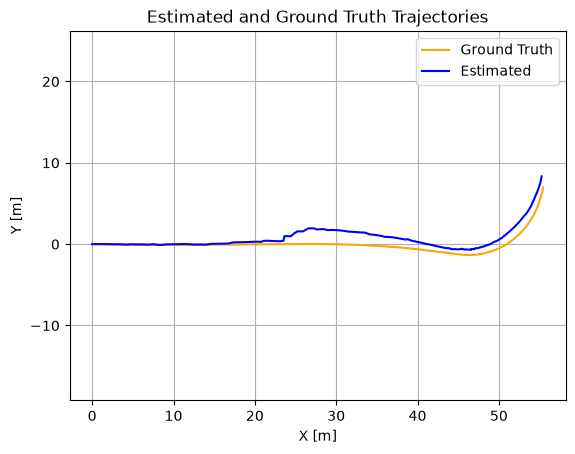

Absolute Trajectory Error (ATE): 1.1230 m


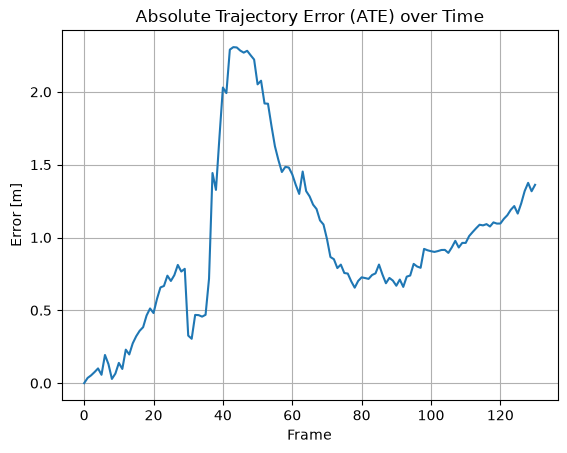

In [39]:
# Load the fixed transform between the KITTI IMU and camera coordinate frame. See last week's practical for more details.
T_cam_imu_matrix = data.camera_calibration(camera=2)['T_cam_imu']
T_cam_imu = SE3.Rt(T_cam_imu_matrix[:3, :3], T_cam_imu_matrix[:3, 3], check=False) # convert it into a spatialmath SE3 object

# We will accumulate our estimated trajectory by chaining the relative motions together. We start with the identity transformation, which represents the initial pose of the camera in the IMU frame.
estimated_trajectory = [SE3()]

# now loop over all the relative motions and update the estimated trajectory by chaining the relative motions together.
# We also need to transform the relative motions from the camera frame to the IMU frame using the fixed transform between the KITTI IMU and camera coordinate frame.
for T in relative_motion:
    relative_motion_in_imu_frame = T_cam_imu.inv() @ T @ T_cam_imu
    estimated_trajectory.append(estimated_trajectory[-1] @ relative_motion_in_imu_frame)

# convert to numpy array for plotting
estimated_trajectory = np.array([pose.t for pose in estimated_trajectory])
    
    
# now we can extract the translation vectors from the estimated trajectory and the ground truth trajectory for plotting. 
# The ground truth poses are already in the IMU frame, so we can directly compare them with the estimated poses.
ground_truth_trajectory = [data.ground_truth_pose(frame) for frame in range(data.frame_count)]
ground_truth_positions = np.array([pose.t for pose in ground_truth_trajectory])

# plot the two trajectories
# Remember that in the IMU frame, the x-axis points forward, the y-axis points to the left, and the z-axis points up. 
# Forward-motion of the car therefore is along the x-axis in the plot.
plt.plot(ground_truth_positions[:, 0], ground_truth_positions[:, 1], label='Ground Truth', color='orange')
plt.plot(estimated_trajectory[:, 0], estimated_trajectory[:, 1],  label='Estimated', color='blue')
plt.xlabel('X [m]')
plt.ylabel('Y [m]')
plt.axis('equal')
plt.title('Estimated and Ground Truth Trajectories')
plt.legend()
plt.grid()
plt.show()

# We can also calculate the absolute trajectory error (ATE) between the estimated trajectory and the ground truth trajectory. 
# The ATE is defined as the root mean square error (RMSE) of the translation vectors between the estimated and ground truth poses.
# We can therefore calculate the ATE as follows:
ate = np.sqrt(np.mean(np.sum((estimated_trajectory - ground_truth_positions) ** 2, axis=1)))
print(f"Absolute Trajectory Error (ATE): {ate:.4f} m")


# Hint: If you make changes to the PnP implementation, you can re-run this code cell to see how the ATE changes. 
# You can try different settings for the PnP algorithms and see how they affect the ATE. 
# For example, you can try different RANSAC parameters, different PnP methods, or different initial guesses for the iterative PnP refinement. 
# You can also try using different feature detectors and descriptors, or different matching strategies.

# We can also plot the error over time to see how the error evolves over the sequence. We can calculate the error at each frame as the Euclidean distance between the estimated and ground truth positions.
errors = np.sqrt(np.sum((estimated_trajectory - ground_truth_positions) ** 2, axis=1))
plt.plot(errors)
plt.xlabel('Frame')
plt.ylabel('Error [m]')
plt.title('Absolute Trajectory Error (ATE) over Time')
plt.grid()
plt.show()